# End-to-End Fine-tuning: PhoBERT + TF-IDF Hybrid (OPTIMIZED)

## Key Optimizations:
1. **Fixed SMOTE issue** - Now uses WeightedRandomSampler instead of SMOTE to avoid modality mismatch
2. **Macro-F1 selection** - Uses macro-F1 for model selection (not weighted-F1)
3. **Gradual unfreezing** - PhoBERT layers are gradually unfrozen
4. **Discriminative learning rates** - Different LR for PhoBERT vs classifier head
5. **Better fusion** - LayerNorm after concatenation, improved architecture
6. **Per-class metrics tracking** - Monitors Neutral class F1 during training

## 1. Setup và Import Libraries

In [3]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [4]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, preprocess_vietnamese

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [5]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    MODEL_TYPE = 'PhoBERT_TF-IDF_E2E_Optimized'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 8
    EARLY_STOP_PATIENCE = 3
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    # Gradual unfreezing schedule
    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 5e-5

    # Unfreezing epochs
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4  # Last N layers to unfreeze in partial stage

    # TF-IDF config
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True

    TFIDF_PROJ_DIM = 256
    CLASSIFIER_HIDDEN_DIM = 256

    # Selection metric - CRITICAL: use macro-F1
    SELECTION_METRIC = 'f1_macro'

    # Class imbalance handling
    USE_WEIGHTED_SAMPLER = True  # Better than SMOTE for multimodal data

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

print('='*60)
print('OPTIMIZED CONFIGURATION')
print('='*60)
print(f'Model: {config.MODEL_NAME}')
print(f'TF-IDF Features: {config.TFIDF_MAX_FEATURES}')
print(f'Batch Size: {config.BATCH_SIZE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Selection Metric: {config.SELECTION_METRIC}')
print(f'Weighted Sampler: {config.USE_WEIGHTED_SAMPLER}')
print(f'Gradual Unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH-1}, full@{config.FULL_UNFREEZE_EPOCH}+')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')

OPTIMIZED CONFIGURATION
Model: vinai/phobert-base
TF-IDF Features: 5000
Batch Size: 16
Epochs: 8
Selection Metric: f1_macro
Weighted Sampler: True
Gradual Unfreezing: freeze<2, partial@2-3, full@4+
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_E2E_Optimized/improvements/20260318_085728


## 3. Load Data

In [6]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. TF-IDF Feature Extraction

In [7]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=config.TFIDF_MIN_DF,
    max_df=config.TFIDF_MAX_DF,
    sublinear_tf=config.TFIDF_SUBLINEAR_TF
)

train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)

joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
print(f'TF-IDF shapes: Train={train_tfidf.shape}, Val={val_tfidf.shape}, Test={test_tfidf.shape}')

TF-IDF shapes: Train=(11426, 5000), Val=(1583, 5000), Test=(3166, 5000)


## 5. Dataset & Model Definition

In [8]:
class HybridDataset(Dataset):
    """Dataset for hybrid PhoBERT + TF-IDF features"""
    def __init__(self, texts, tfidf_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tfidf = self.tfidf_features[idx]
        if hasattr(tfidf, 'toarray'):
            tfidf = tfidf.toarray().ravel()

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [9]:
class PhoBERTTFIDFHybridOptimized(nn.Module):
    """Optimized Hybrid model: PhoBERT (fine-tuned with gradual unfreezing) + TF-IDF features

    Key improvements:
    1. LayerNorm after concatenation for better feature fusion
    2. Better dropout placement
    3. Projection layers with residual-like connections
    """
    def __init__(self, model_name, tfidf_dim, num_classes, dropout=0.3):
        super(PhoBERTTFIDFHybridOptimized, self).__init__()

        # PhoBERT encoder
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size  # 768

        # TF-IDF projection with LayerNorm
        self.tfidf_proj = nn.Sequential(
            nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM),
            nn.LayerNorm(config.TFIDF_PROJ_DIM),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Combined features LayerNorm for better fusion
        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM
        self.fusion_norm = nn.LayerNorm(combined_dim)

        # Classifier with LayerNorm
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def forward(self, input_ids, attention_mask, tfidf_features):
        # PhoBERT forward
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        phobert_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token

        # TF-IDF projection
        tfidf_proj = self.tfidf_proj(tfidf_features)

        # Concatenate and apply LayerNorm for fusion
        combined = torch.cat([phobert_emb, tfidf_proj], dim=1)
        combined = self.fusion_norm(combined)

        # Classification
        logits = self.classifier(combined)
        return logits


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFHybridOptimized(
    model_name=config.MODEL_NAME,
    tfidf_dim=config.TFIDF_MAX_FEATURES,
    num_classes=config.NUM_CLASSES,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 136,544,771
Initial trainable parameters: 136,544,771


## 6. Create DataLoaders with WeightedRandomSampler

**Key fix**: Instead of SMOTE (which creates modality mismatch), we use WeightedRandomSampler.
This ensures each sample is kept intact (text + TF-IDF are always from the same sample).

In [10]:
# Convert TF-IDF to dense for DataLoader
train_tfidf_dense = train_tfidf.toarray() if hasattr(train_tfidf, 'toarray') else np.array(train_tfidf)
val_tfidf_dense = val_tfidf.toarray() if hasattr(val_tfidf, 'toarray') else np.array(val_tfidf)
test_tfidf_dense = test_tfidf.toarray() if hasattr(test_tfidf, 'toarray') else np.array(test_tfidf)

# Create datasets
train_dataset = HybridDataset(train_texts, train_tfidf_dense, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf_dense, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf_dense, test_labels, tokenizer, config.MAX_LENGTH)

# WeightedRandomSampler for class imbalance
if config.USE_WEIGHTED_SAMPLER:
    class_counts = Counter(train_labels)
    num_samples = len(train_labels)

    # Weight for each sample (inverse of class frequency)
    class_weights = {cls: num_samples / (len(class_counts) * count) for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in train_labels]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=num_samples,
        replacement=True
    )
    print(f'Class weights for sampler: {class_weights}')
    print(f'Using WeightedRandomSampler instead of SMOTE')
else:
    sampler = None

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    sampler=sampler,  # Use sampler instead of shuffle
    shuffle=False if sampler else True
)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Class weights for sampler: {2: 0.674936499497903, 0: 0.7152425665101722, 1: 8.315866084425036}
Using WeightedRandomSampler instead of SMOTE
Train batches: 715
Val batches: 99
Test batches: 198


## 7. Training Setup with Gradual Unfreezing

In [11]:
# Compute class weights for loss function
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=np.array(train_labels)
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Class weights for loss: {class_weights.tolist()}')


def get_training_stage(epoch_number):
    """Determine training stage based on epoch number."""
    if epoch_number < config.PARTIAL_UNFREEZE_EPOCH:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'


def set_phobert_trainable_layers(model, stage):
    """Set PhoBERT layers trainable based on training stage."""
    # First freeze all PhoBERT parameters
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        # Unfreeze last N encoder layers
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        # Unfreeze all PhoBERT parameters
        for param in model.phobert.parameters():
            param.requires_grad = True

    # Always keep projection and classifier trainable
    for module in [model.tfidf_proj, model.classifier]:
        for param in module.parameters():
            param.requires_grad = True


def build_optimizer_and_scheduler(model, stage, epoch_number):
    """Build optimizer with discriminative learning rates."""
    phobert_lr = {
        'frozen': config.PHOBERT_LR_FROZEN,
        'partial': config.PHOBERT_LR_PARTIAL,
        'full': config.PHOBERT_LR_FULL
    }[stage]

    optimizer_groups = []

    # PhoBERT parameters (if trainable)
    phobert_params = [p for p in model.phobert.parameters() if p.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})

    # Head parameters (always trainable with higher LR)
    head_params = [p for module in [model.tfidf_proj, model.classifier] for p in module.parameters() if p.requires_grad]
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})

    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)

    # Calculate remaining steps for scheduler
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps


# Initial setup - freeze PhoBERT
set_phobert_trainable_layers(model, 'frozen')
print(f'Trainable params after freeze: {count_trainable_params(model):,}')

Class weights for loss: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze: 1,546,499


## 8. Training Loop

In [12]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, tfidf)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1_macro


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, tfidf)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)

    # Per-class metrics
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }

In [13]:
# Training loop
history = {
    'epoch': [], 'stage': [],
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_neutral': [],
    'phobert_lr': [], 'trainable_params': []
}

best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('='*70)
print('START TRAINING WITH GRADUAL UNFREEZING')
print('='*70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)

    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')

    print(f'\nEpoch {epoch}/{config.EPOCHS}')

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_neutral'].append(val_metrics['f1_per_class'][1])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))

    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")

    # Model selection based on MACRO F1 (critical fix)
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> New best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)

print(f'\nBest epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')

START TRAINING WITH GRADUAL UNFREEZING

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=1,546,499

Epoch 1/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.5278 acc=0.4119 f1_macro=0.3332
Val    - loss=0.7647 acc=0.6456 f1_macro=0.5632 f1_neutral=0.2162
  -> New best model saved (val macro F1=0.5632)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=29,897,987

Epoch 2/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0112 acc=0.9880 f1_macro=0.9879
Val    - loss=1.0935 acc=0.9400 f1_macro=0.8312 f1_neutral=0.5821
  -> No improvement, patience=1/3

Epoch 8/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0104 acc=0.9885 f1_macro=0.9885
Val    - loss=1.1107 acc=0.9419 f1_macro=0.8362 f1_neutral=0.5954
  -> New best model saved (val macro F1=0.8362)

Best epoch: 8, best stage: full, best val macro F1: 0.8362


## 9. Evaluation on Test Set

In [14]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation Classification Report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

print('\nTest Classification Report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.97      0.95       705
     Neutral       0.67      0.53      0.60        73
    Positive       0.97      0.96      0.96       805

    accuracy                           0.94      1583
   macro avg       0.86      0.82      0.84      1583
weighted avg       0.94      0.94      0.94      1583


Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.97      0.94      1409
     Neutral       0.66      0.35      0.46       167
    Positive       0.94      0.95      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.84      0.76      0.78      3166
weighted avg       0.92      0.93      0.92      3166



## 10. Save Results

In [15]:
# Summary dataframe
summary_df = pd.DataFrame([
    {
        'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'],
        'F1_Weighted': val_results['f1_weighted'],
        'F1_Negative': val_results['f1_per_class'][0],
        'F1_Neutral': val_results['f1_per_class'][1],
        'F1_Positive': val_results['f1_per_class'][2]
    },
    {
        'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'],
        'F1_Weighted': test_results['f1_weighted'],
        'F1_Negative': test_results['f1_per_class'][0],
        'F1_Neutral': test_results['f1_per_class'][1],
        'F1_Positive': test_results['f1_per_class'][2]
    },
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

# Training results text
with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('='*60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF End-to-End (OPTIMIZED)\n')
    f.write('='*60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f'Test Accuracy: {test_results["accuracy"]:.4f}\n')
    f.write(f'Test F1 Macro: {test_results["f1_macro"]:.4f}\n')
    f.write(f'Test F1 Weighted: {test_results["f1_weighted"]:.4f}\n')
    f.write(f'Test F1 Neutral: {test_results["f1_per_class"][1]:.4f}\n')

print(f'Saved outputs to: {config.RESULTS_DIR}')

,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,8,full,0.941883,0.836217,0.940213,0.952580,0.595420,0.960650
1,Test,8,full,0.925458,0.783140,0.919557,0.944194,0.459144,0.946082


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_E2E_Optimized/improvements/20260318_085728


## 11. Visualization

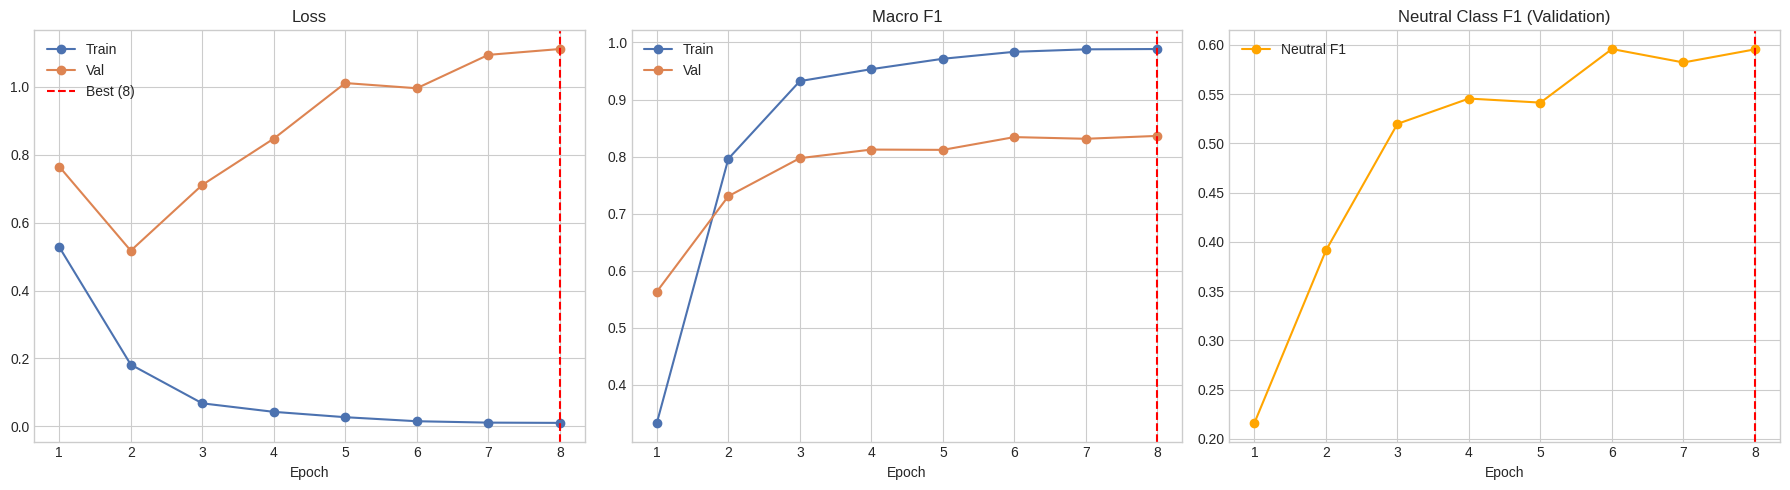

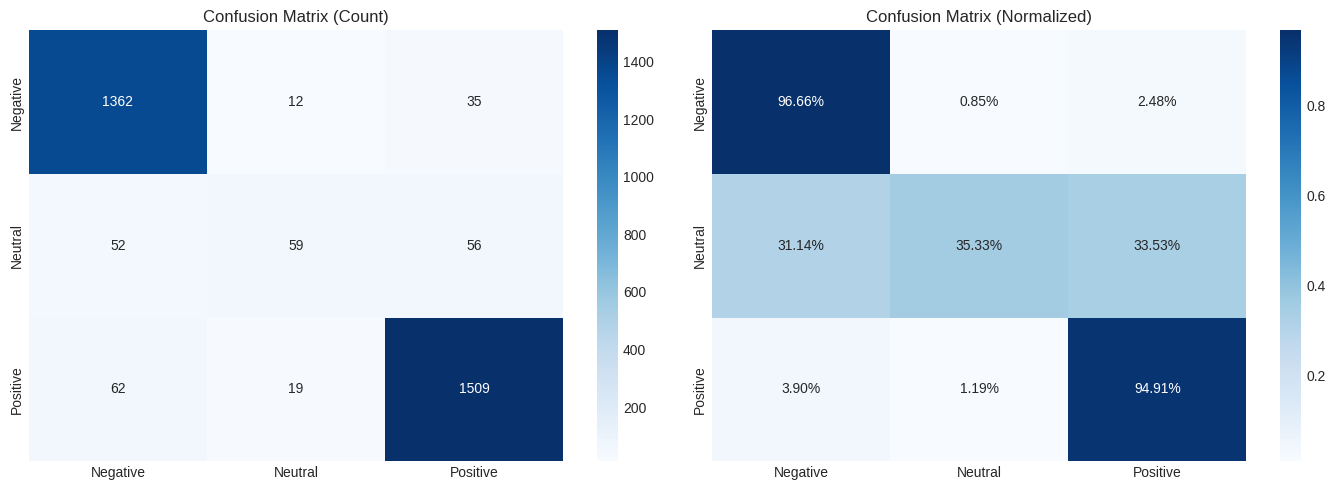

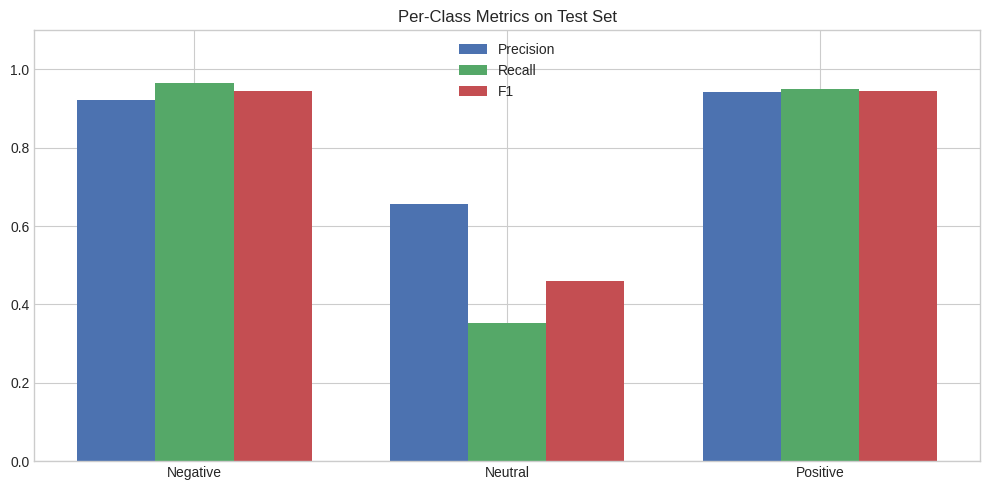

In [16]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--')
axes[1].set_title('Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_f1_neutral'], marker='o', color='orange', label='Neutral F1')
axes[2].axvline(best_epoch, color='red', linestyle='--')
axes[2].set_title('Neutral Class F1 (Validation)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class metrics
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(config.LABEL_MAP))
width = 0.25
ax.bar(x - width, test_results['precision_per_class'], width, label='Precision', color='#4C72B0')
ax.bar(x, test_results['recall_per_class'], width, label='Recall', color='#55A868')
ax.bar(x + width, test_results['f1_per_class'], width, label='F1', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(list(config.LABEL_MAP.values()))
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Error Analysis for Neutral Class

In [17]:
# Find misclassified Neutral samples
neutral_indices = [i for i, label in enumerate(test_results['y_true']) if label == 1]
misclassified_neutral = [
    (i, test_results['y_pred'][i], test_texts[i])
    for i in neutral_indices
    if test_results['y_pred'][i] != 1
]

print(f'Total Neutral samples: {len(neutral_indices)}')
print(f'Misclassified Neutral: {len(misclassified_neutral)}')
print(f'Neutral accuracy: {1 - len(misclassified_neutral)/len(neutral_indices):.2%}')

print('\n--- Sample Misclassified Neutral Feedback ---')
for idx, pred, text in misclassified_neutral[:10]:
    pred_label = config.LABEL_MAP[pred]
    print(f'  Predicted: {pred_label} | Text: "{text[:80]}..."' if len(text) > 80 else f'  Predicted: {pred_label} | Text: "{text}"')

# Count which classes Neutral is confused with
from collections import Counter
confusion_targets = Counter([pred for _, pred, _ in misclassified_neutral])
print(f'\nNeutral confusion targets:')
for cls, count in sorted(confusion_targets.items()):
    print(f'  {config.LABEL_MAP[cls]}: {count}')

Total Neutral samples: 167
Misclassified Neutral: 108
Neutral accuracy: 35.33%

--- Sample Misclassified Neutral Feedback ---
  Predicted: Positive | Text: "cách mà cô tiếp cận với sinh viên"
  Predicted: Positive | Text: "môn học này giúp chúng em hiểu ra những vấn đề cơ bản"
  Predicted: Positive | Text: "như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết"
  Predicted: Positive | Text: "ví dụ phù hợp với nội dung kiến thức hướng dẫn chị tiết"
  Predicted: Positive | Text: "tâm lý"
  Predicted: Positive | Text: "kỹ những chương cuối"
  Predicted: Positive | Text: "cả cuộc sống sau này lẫn trong môn học"
  Predicted: Positive | Text: "cô cho em 10 điểm thực hành colonlove"
  Predicted: Positive | Text: "đã có làm đơn với phòng đào tạo"
  Predicted: Positive | Text: "có kết hợp với bài tập ví dụ"

Neutral confusion targets:
  Negative: 52
  Positive: 56


## 13. Final Summary

In [18]:
print('='*70)
print('OPTIMIZED MODEL - FINAL SUMMARY')
print('='*70)

print('\nKey Optimizations Applied:')
print('  1. WeightedRandomSampler instead of SMOTE (fixes modality mismatch)')
print('  2. Macro-F1 for model selection (not weighted-F1)')
print('  3. Gradual unfreezing: frozen -> partial -> full')
print('  4. Discriminative learning rates')
print('  5. LayerNorm after concatenation for better fusion')

print(f'\nBest epoch: {best_epoch}')
print(f'Best stage: {best_stage}')
print(f'Best val macro F1: {best_val_f1:.4f}')

print(f'\nTest Results:')
print(f'  Accuracy: {test_results["accuracy"]:.4f}')
print(f'  F1 Macro: {test_results["f1_macro"]:.4f}')
print(f'  F1 Weighted: {test_results["f1_weighted"]:.4f}')

print('\nPer-Class F1:')
for i, name in config.LABEL_MAP.items():
    print(f'  {name}: {test_results["f1_per_class"][i]:.4f}')

print('\n' + '='*70)

OPTIMIZED MODEL - FINAL SUMMARY

Key Optimizations Applied:
  1. WeightedRandomSampler instead of SMOTE (fixes modality mismatch)
  2. Macro-F1 for model selection (not weighted-F1)
  3. Gradual unfreezing: frozen -> partial -> full
  4. Discriminative learning rates
  5. LayerNorm after concatenation for better fusion

Best epoch: 8
Best stage: full
Best val macro F1: 0.8362

Test Results:
  Accuracy: 0.9255
  F1 Macro: 0.7831
  F1 Weighted: 0.9196

Per-Class F1:
  Negative: 0.9442
  Neutral: 0.4591
  Positive: 0.9461

